# Лаба 233

### Необходимые импорты и доп.функции

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline # Для СВ
from scipy.optimize import curve_fit

In [ ]:
def check_len(arr1, arr2):
    if len(arr1) != len(arr2):
        raise ValueError(f"Длины массивов не совпадают: {len(arr1)} != {len(arr2)}")

## Часть 1
## Распределение напряженности поля по длине волновода и для разных нагрузок

$$\boxed{КСВ(Н) =  \sqrt{\frac{A_{max}}{A_{min}}}}$$
На первой лекции была дана формула:
$$\boxed{КСВ(Н) =  \frac{1 + |r|}{1 - |r|}}$$
$$\Downarrow$$
$${|r| =  \frac{КСВ(Н) - 1}{КСВ(Н) + 1}}$$

### Необходимые функции

In [23]:
def calculate_KSVN(arr_mv: np.ndarray):
    A_max = arr_mv.max()
    A_min = arr_mv.min()
    if A_min == 0:
        return float('inf')  # КСВН = бесконечность
    return np.sqrt(A_max / A_min)

def calculate_r(KSVN):
    if KSVN == float('inf'):
        return 1
    return (KSVN - 1) / (KSVN + 1)

def find_lambda(arr_mv: np.ndarray, arr_mm: np.ndarray):
    sorted_indices = np.argsort(arr_mv)
    x1_A_min = arr_mm[sorted_indices[0]]
    x2_A_min = arr_mm[sorted_indices[1]]
    return 2 * np.abs(x1_A_min - x2_A_min)

### Данные
Измерения проводятся в пределах 1-2-ух длин волн (сантиметровые)

Волновод имеет размеры 7.2 x 3.4 мм

0. Согласованная нагрузка

In [24]:
min_SN = 164 # mv
max_SN = 169 # mv
KSVN_SN = np.sqrt(max_SN / min_SN)
r_SN = calculate_r(KSVN_SN)
print(f'Для согласованной нагрузки КСВН = {KSVN_SN:.4f}, r = {r_SN:.4f}')

Для согласованной нагрузки КСВН = 1.0151, r = 0.0075


1. Короткое замыкание

In [25]:
mv_KZ =  np.array([2, 98, 250, 364, 412, 414, 390, 280, 146, 16, 0])
mm_KZ = np.array([11, 12, 13, 14, 15, 15.2, 16, 17, 18, 19, 19.4]) + 0.2 # + 11/20 у всех
check_len(mv_KZ, mm_KZ)

KSVN_KZ = calculate_KSVN(mv_KZ)
lambda_KZ = find_lambda(mv_KZ, mm_KZ)
r_KZ = calculate_r(KSVN_KZ)
print(f'Для короткого замыкания КСВН = {KSVN_KZ:.4f}, λ = {lambda_KZ:.2f} мм, r = {r_KZ:.4f}')

Для короткого замыкания КСВН = inf, λ = 16.80 мм, r = 1.0000


2. Открытый конец волновода

In [26]:
mv_OK = np.array([148, 120, 134, 172, 210, 236, 240, 232, 204, 166, 126, 122, 152])
mm_OK = np.array([21, 22.4, 23, 24, 25, 26, 26.65, 27, 28, 29, 30, 30.5, 32])
check_len(mv_OK, mm_OK)

KSVN_OK = calculate_KSVN(mv_OK)
lambda_OK = find_lambda(mv_OK, mm_OK)
r_OK = calculate_r(KSVN_OK)
print(f'Для открытого конца КСВН = {KSVN_OK:.4f}, λ = {lambda_OK:.2f} мм, r = {r_OK:.4f}')

Для открытого конца КСВН = 1.4142, λ = 16.20 мм, r = 0.1716


3. Диэлектрик (сильно поглощающая диэлектрическая пластина у открытого конца)

In [27]:
mv_DLK =  np.array([100, 74, 94, 160, 224, 268 , 276, 272, 232, 166, 96, 76, 78, 120])
mm_DLK = np.array([10.5, 11.5, 12, 13, 14, 15, 15.5, 16, 17, 18, 19, 19.7, 20, 21])
check_len(mv_DLK, mm_DLK)

KSVN_DLK = calculate_KSVN(mv_DLK)
lambda_DLK = find_lambda(mv_DLK, mm_DLK)
r_DLK = calculate_r(KSVN_DLK)
print(f'Для диэлетрика КСВН = {KSVN_DLK:.4f}, λ = {lambda_DLK:.2f} мм, r = {r_DLK:.4f}')

Для диэлетрика КСВН = 1.9313, λ = 16.40 мм, r = 0.3177


4. Рупор

In [28]:
mv_RUP =  np.array([146, 144, 153, 169, 185, 191, 184, 170, 155, 145, 148])
mm_RUP = np.array([24, 24.6, 26, 27, 28, 29, 30, 31, 32, 33, 34])
check_len(mv_RUP, mm_RUP)

KSVN_RUP = calculate_KSVN(mv_RUP)
lambda_RUP = find_lambda(mv_RUP, mm_RUP)
r_RUP = calculate_r(KSVN_RUP)
print(f'Для рупора КСВН = {KSVN_RUP:.4f}, λ = {lambda_RUP:.2f} мм, r = {r_RUP:.4f}')

Для рупора КСВН = 1.1517, λ = 16.80 мм, r = 0.0705


### Отрисовка графиков


In [29]:
def draw_grafics(arr_mm: np.ndarray, arr_mv: np.ndarray, title: str):
    plt.figure(figsize=(9, 6))

    plt.scatter(arr_mm, arr_mv,  color='b', label='Эксп', marker='o')


    # Создаём много точек для плавной линии
    d_smooth = np.linspace(arr_mm.min(), arr_mm.max(), 300)
    spline = make_interp_spline(arr_mm, arr_mv, k=3)  # k=3 — кубический сплайн
    U_smooth = spline(d_smooth)
    plt.plot(d_smooth, U_smooth, '-', linewidth=2, label='Сглаженная кривая', color='blue')
    plt.title(f'График распределения напряженности поля вдоль волновода {title}')
    plt.xlabel('мм')
    plt.ylabel('мВ')
    plt.grid(True)
    ax = plt.gca()                             # СВ просил делать сетку мельче
    ax.locator_params(axis='x', nbins=25)
    ax.locator_params(axis='y', nbins=25)
    plt.xticks(rotation=45)  # поворот на 45 градусов
    plt.legend()

    plt.show()

In [ ]:
# Код дипсика
def draw_grafics(arr_mm: np.ndarray, arr_mv: np.ndarray, title: str):
    plt.figure(figsize=(9, 6))

    # Исходные точки
    plt.scatter(arr_mm, arr_mv, color='b', label='Эксп', marker='o')

    # 1. Синусоидальная аппроксимация
    def sin_func(x, A, B, C, D):
        """ A * sin(B*x + C) + D """
        return A * np.sin(B * x + C) + D
    
    # Подбираем параметры
    p0 = [np.ptp(arr_mv)/2, 2*np.pi/(arr_mm[-1]-arr_mm[0]), 0, np.mean(arr_mv)]  # начальные приближения
    params, _ = curve_fit(sin_func, arr_mm, arr_mv, p0=p0)
    A, B, C, D = params
    
    # Сглаженная кривая (сплайн)
    d_smooth = np.linspace(arr_mm.min(), arr_mm.max(), 300)
    spline = make_interp_spline(arr_mm, arr_mv, k=3)
    U_smooth = spline(d_smooth)
    plt.plot(d_smooth, U_smooth, '-', linewidth=2, label='Сглаженная кривая', color='blue')
    
    # Синусоидальная аппроксимация
    sin_fit = sin_func(d_smooth, A, B, C, D)
    plt.plot(d_smooth, sin_fit, '--', linewidth=2, label=f'Синус: {A:.2f}·sin({B:.3f}x + {C:.2f}) + {D:.2f}', color='red')
    
    plt.title(f'График распределения напряженности поля вдоль волновода {title}')
    plt.xlabel('мм')
    plt.ylabel('мВ')
    plt.grid(True)
    ax = plt.gca()
    ax.locator_params(axis='x', nbins=25)
    ax.locator_params(axis='y', nbins=25)
    plt.xticks(rotation=45)
    plt.legend()
    plt.show()
    
    print(f"Параметры синусоиды:")
    print(f"  A (амплитуда) = {A:.4f}")
    print(f"  B (частота) = {B:.4f}")
    print(f"  C (фаза) = {C:.4f}")
    print(f"  D (смещение) = {D:.4f}")

1. Короткое замыкание

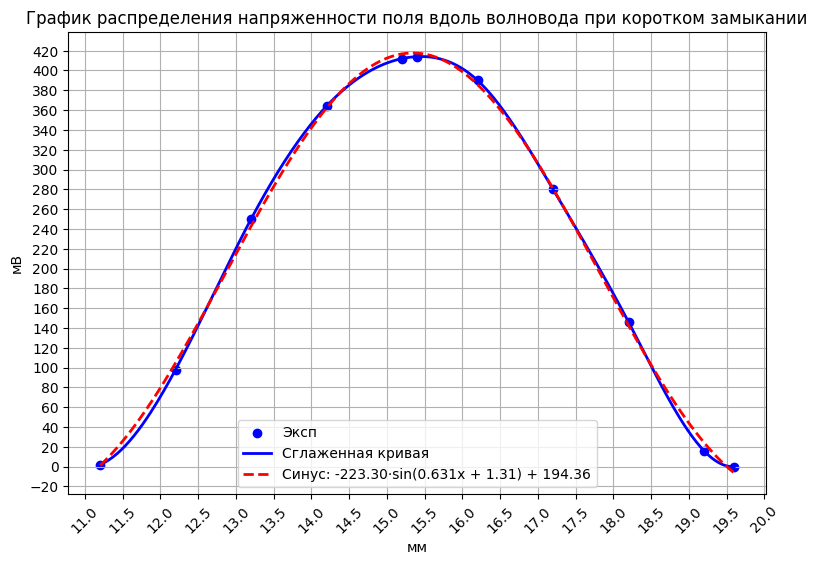

Параметры синусоиды:
  A (амплитуда) = -223.2969
  B (частота) = 0.6315
  C (фаза) = 1.3079
  D (смещение) = 194.3611
λ = 16.80 мм 


In [31]:
draw_grafics(mm_KZ, mv_KZ, 'при коротком замыкании')
print(f'λ = {lambda_KZ:.2f} мм ')

2. Открытый конец волновода

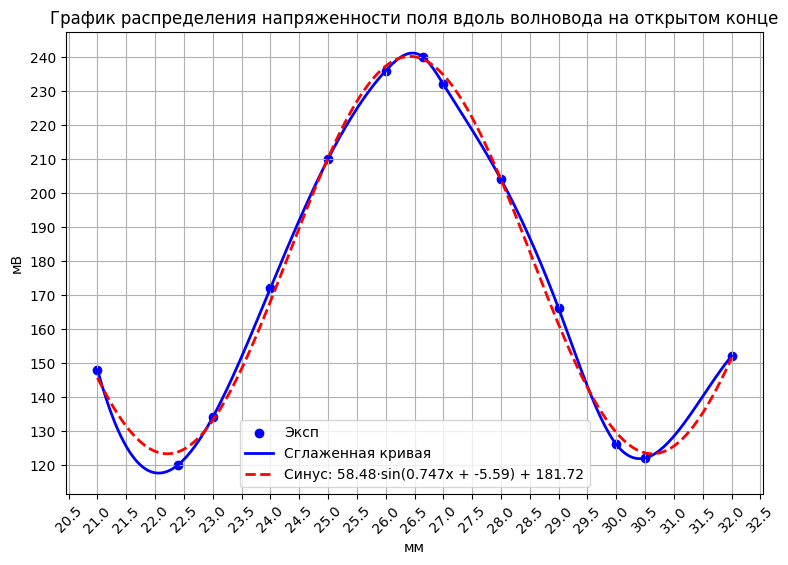

Параметры синусоиды:
  A (амплитуда) = 58.4786
  B (частота) = 0.7468
  C (фаза) = -5.5927
  D (смещение) = 181.7161
λ = 16.20 мм 


In [32]:
draw_grafics(mm_OK, mv_OK, 'на открытом конце')
print(f'λ = {lambda_OK:.2f} мм ')

3. Диэлектрик (сильно поглощающая диэлектрическая пластина у открытого конца)

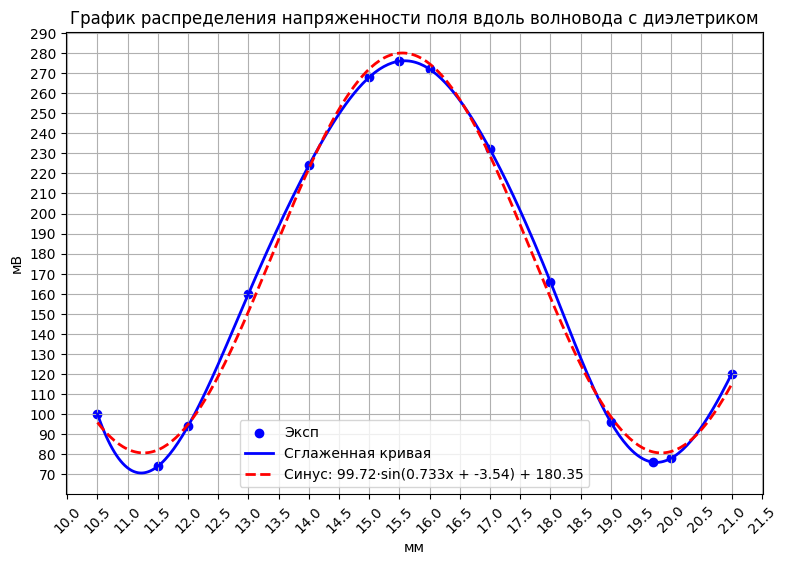

Параметры синусоиды:
  A (амплитуда) = 99.7165
  B (частота) = 0.7329
  C (фаза) = -3.5420
  D (смещение) = 180.3502
λ = 16.40 мм 


In [33]:
draw_grafics(mm_DLK, mv_DLK, 'с диэлетриком')
print(f'λ = {lambda_DLK:.2f} мм ')

4. Рупор

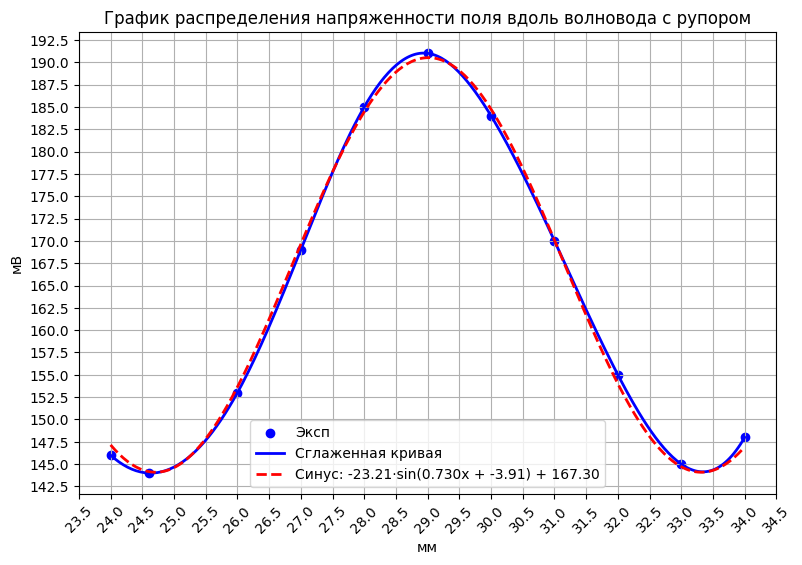

Параметры синусоиды:
  A (амплитуда) = -23.2121
  B (частота) = 0.7302
  C (фаза) = -3.9077
  D (смещение) = 167.3020
λ = 16.80 мм 


In [34]:
draw_grafics(mm_RUP, mv_RUP, 'с рупором')
print(f'λ = {lambda_RUP:.2f} мм ')

### Определение диэлектрической проницаемости
$$ r = \frac{n_1 - n_2}{n_1 + n_2}$$
$$n_1 = 1 $$ $$ n_2 \approx \sqrt{\varepsilon}$$
$$\Downarrow$$
$$ r = \frac{1 - \sqrt{\varepsilon}}{1 + \sqrt{\varepsilon}}$$
$$\Downarrow$$
$$\boxed{\varepsilon = \left( \frac{1 - r}{1 + r} \right)^2}$$

Также помним:
$$|r| = \frac{КСВ(Н) - 1}{КСВ(Н) + 1}$$

Так как пластина находится в конце волновода (отражение от диэлектрика): $r = -|r|$

$$r = -\frac{КСВ(Н) - 1}{КСВ(Н) + 1}$$
$$\Downarrow$$
$$\varepsilon = \left( \frac{1 - r}{1 + r} \right)^2 = КСВ(Н)^2$$

Таким образом:

$$\boxed{\varepsilon = \text{КСВ(Н)}^2}$$

In [35]:
eps = KSVN_DLK**2
print(f'Диэлетрическая проницаемость ε = {eps:.4f}')

Диэлетрическая проницаемость ε = 3.7297


## Часть 4
## Полное внутреннее отражение на диэлектрической призме

### Теоретические формулы для нарушенного ПВО (дипсик)

**Условие полного внутреннего отражения:**

$$\theta_i > \theta_{кр} = \arcsin\left(\frac{n_2}{n_1}\right)$$

**Коэффициент затухания эванесцентной волны:**

$$\kappa = \frac{2\pi}{\lambda} \sqrt{n_1^2 \sin^2\theta_i - n_2^2}$$

**Интенсивность прошедшего сигнала:**

$$I(d) = I_0 \cdot e^{-2\kappa d}$$

**Глубина проникновения (расстояние, на котором поле убывает в $e$ раз):**

$$\delta = \frac{1}{\kappa} = \frac{\lambda}{2\pi \sqrt{n_1^2 \sin^2\theta_i - n_2^2}}$$

**В полулогарифмических координатах:**

$$\ln\left(\frac{I(d)}{I_0}\right) = -2\kappa \cdot d$$

### Данные

In [36]:
mv_PRZM =  np.array([287, 275, 267, 248, 196, 131, 75, 48, 42, 38, 31, 22, 12, 0])
mm_PRZM = np.array(list(range(0, 14)))
check_len(mv_PRZM, mm_PRZM)


### Отрисовка графиков

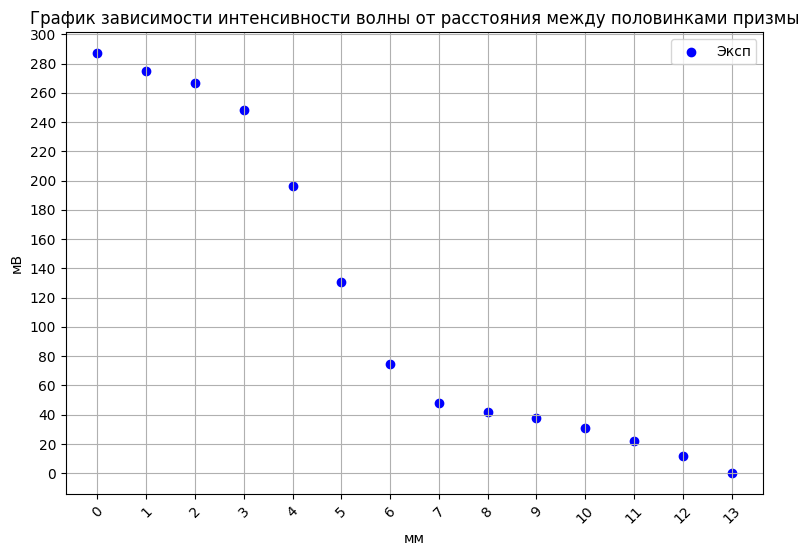

In [37]:
plt.figure(figsize=(9, 6))

plt.scatter(mm_PRZM, mv_PRZM,  color='b', label='Эксп', marker='o')

plt.title(f'График зависимости интенсивности волны от расстояния между половинками призмы')
plt.xlabel('мм')
plt.ylabel('мВ')
plt.grid(True)
ax = plt.gca()
ax.locator_params(axis='x', nbins=25)
ax.locator_params(axis='y', nbins=25)
plt.xticks(rotation=45)  # поворот на 45 градусов
plt.legend()

plt.show()

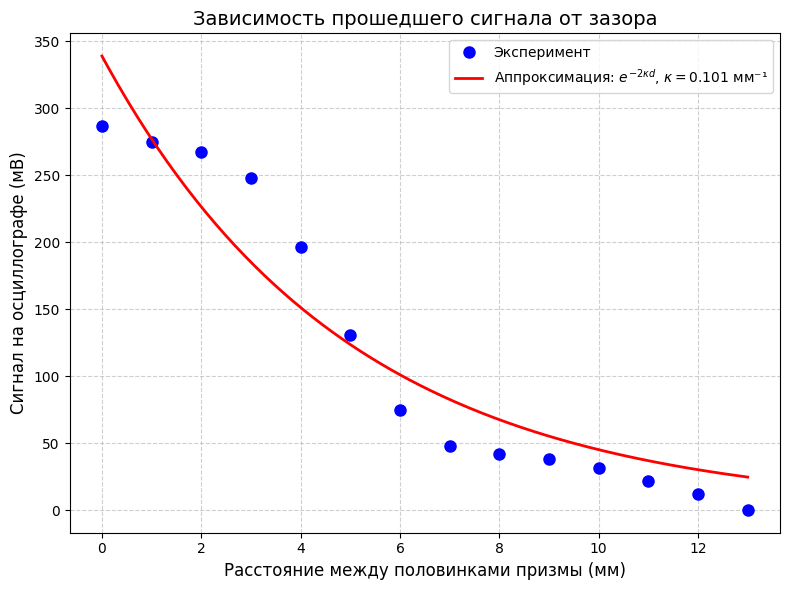

In [ ]:
# Код дипсика
# Теоретическая функция: экспоненциальное затухание
def exp_decay(d, I0, kappa):
    return I0 * np.exp(-2 * kappa * d)

# Аппроксимация экспериментальных данных
popt, pcov = curve_fit(exp_decay, mm_PRZM, mv_PRZM, p0=[100, 0.5])
I0_fit, kappa_fit = popt

# Создаём ПЛАВНУЮ кривую (много точек для гладкости)
d_smooth = np.linspace(0, max(mm_PRZM), 200)
U_smooth = exp_decay(d_smooth, I0_fit, kappa_fit)

# Строим график
plt.figure(figsize=(8, 6))

# Экспериментальные точки (только точки, без линий!)
plt.plot(mm_PRZM, mv_PRZM, 'o', markersize=8, label='Эксперимент', color='blue')

# Теоретическая плавная кривая
plt.plot(d_smooth, U_smooth, '-', linewidth=2, label=f'Аппроксимация: $e^{{-2\\kappa d}}$, $\\kappa = {kappa_fit:.3f}$ мм⁻¹', color='red')

plt.xlabel('Расстояние между половинками призмы (мм)', fontsize=12)
plt.ylabel('Сигнал на осциллографе (мВ)', fontsize=12)
plt.title('Зависимость прошедшего сигнала от зазора', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()